# LLM policies
Compare to the common policies used for LLMs.
Compares the Pareto frontier (TTFF vs Cost) of the allocator policies using the default **Podcast** workflow (10-minute video from PDF + text prompt):

- **StreamWise** policy (greedy allocator with streamwise policy)
- **HexGen** policy (hexgen allocator)
- **Helix** policy (helix allocator)
- **DDiT** policy (greedy allocator with DDiT policy)

## Setup

In [1]:
from __future__ import annotations

import os
import math

from matplotlib import pyplot as plt

from dataclasses import replace

from constants import SECONDS_IN_HOUR

from data_loading import load_latency_data

from provisioning import get_provisioning_results

from sim_types import ProvisioningResult
from sim_types import GPUType
from sim_types import Objective
from sim_types import num_gpus_to_str
from sim_types import Model

from utils import get_pareto_frontier

from plot_utils import _get_time_ticklabels
from plot_utils import get_color_map

from policies import STREAMWISE_POLICY
from policies import HEXGEN_POLICY
from policies import HELIX_POLICY
from policies import DDIT_POLICY

from workflows import PODCAST_WORKFLOW

from utils import find_most_cost_effective_provisioning
from utils import find_fastest_provisioning

In [2]:
data_dir = "data/"
results_dir = "results/"
results_llm_dir = "results/llm/"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(results_llm_dir, exist_ok=True)

SHORT_LIST = True

In [3]:
latency_data = load_latency_data(data_dir=data_dir)

workflow = PODCAST_WORKFLOW

## Run Provisioning

In [4]:
# both disagg
sw_both_disagg_policy = replace(
    STREAMWISE_POLICY,
    disaggregation = {
        Model.FT: True,
        Model.HF: True,
    }
)
streamwise_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=sw_both_disagg_policy,
    short_list=SHORT_LIST,
)

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [5]:
# no disagg
sw_no_disagg_policy = replace(
    STREAMWISE_POLICY,
    disaggregation={
        Model.HF: False,
        Model.FT: False,
    }
)
streamwise_no_disagg_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=sw_no_disagg_policy,
    short_list=SHORT_LIST,
)

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [6]:
# ft-vae only disagg
sw_ft_only_disagg_policy = replace(
    STREAMWISE_POLICY,
    disaggregation={
        Model.HF: False,
        Model.FT: True,
    }
)

streamwise_ft_only_disagg_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=sw_ft_only_disagg_policy,
    short_list=SHORT_LIST,
)


streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [7]:
# hf-only disagg
sw_hf_only_disagg_policy = replace(
    STREAMWISE_POLICY,
    disaggregation={
        Model.HF: True,
        Model.FT: False,
    }
)
streamwise_hf_only_disagg_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=sw_hf_only_disagg_policy,
    short_list=SHORT_LIST,
)

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [8]:
hexgen_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=HEXGEN_POLICY,
    short_list=SHORT_LIST,
)

hexgen policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [9]:
hexgen_policy_cost_aware = replace(
    HEXGEN_POLICY,
    objective=Objective.TTFF_COST)

hexgen_cost_aware_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=hexgen_policy_cost_aware,
    short_list=SHORT_LIST,
)

hexgen policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [10]:
helix_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=HELIX_POLICY,
    short_list=SHORT_LIST,
)

helix policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [11]:
ddit_results = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=DDIT_POLICY,
    short_list=SHORT_LIST,
)

ddit policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [12]:
from constants import GPU_SPOT_COST

hexgen_policy_using_spot = replace(
    HEXGEN_POLICY,
    gpu_cost=GPU_SPOT_COST)
helix_policy_using_spot = replace(
    HELIX_POLICY,
    gpu_cost=GPU_SPOT_COST)
ddit_policy_using_spot = replace(
    DDIT_POLICY,
    gpu_cost=GPU_SPOT_COST)

hexgen_results_using_spot = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=hexgen_policy_using_spot,
    short_list=SHORT_LIST,
)

helix_results_using_spot = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=helix_policy_using_spot,
    short_list=SHORT_LIST,
)

ddit_results_using_spot = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=ddit_policy_using_spot,
    short_list=SHORT_LIST,
)

hexgen policy:   0%|          | 0/1600 [00:00<?, ?it/s]

helix policy:   0%|          | 0/1600 [00:00<?, ?it/s]

ddit policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [13]:
hexgen_policy_using_spot_cost_aware = replace(
    HEXGEN_POLICY,
    gpu_cost=GPU_SPOT_COST,
    objective=Objective.TTFF_COST)

hexgen_results_using_spot_cost_aware = get_provisioning_results(
    workflow=workflow,
    latency_data=latency_data,
    policy=hexgen_policy_using_spot_cost_aware,
    short_list=SHORT_LIST,
)

hexgen policy:   0%|          | 0/1600 [00:00<?, ?it/s]

## Summary Statistics

In [14]:
for label, res in [
    ("StreamWise", streamwise_results),
    ("StreamWise FT-only Disag", streamwise_ft_only_disagg_results),
    ("StreamWise HF-only Disag", streamwise_hf_only_disagg_results),
    ("StreamWise No Disagg", streamwise_no_disagg_results),
    ("HexGen", hexgen_results),
    ("HexGen Cost-Aware", hexgen_cost_aware_results),
    ("Helix", helix_results),
    ("DDiT", ddit_results),
]:
    idx_ce = find_most_cost_effective_provisioning(res)
    idx_fast = find_fastest_provisioning(res)
    print(f"=== {label} ===")
    print(f"  Provisions evaluated: {len(res.latencies)}")
    print(f"  Most cost-effective: TTFF={res.ttffs[idx_ce]:.1f}s, Cost=${res.costs[idx_ce]:.2f}, GPUs={num_gpus_to_str(res.actual_provision[idx_ce])}")
    print(f"  Fastest:             TTFF={res.ttffs[idx_fast]:.1f}s, Cost=${res.costs[idx_fast]:.2f}, GPUs={num_gpus_to_str(res.actual_provision[idx_fast])}")
    print()

=== StreamWise ===
  Provisions evaluated: 1600
  Most cost-effective: TTFF=23.2s, Cost=$56.70, GPUs=686xA100+71xH200
  Fastest:             TTFF=11.1s, Cost=$151.91, GPUs=469xGB200

=== StreamWise FT-only Disag ===
  Provisions evaluated: 1600
  Most cost-effective: TTFF=24.4s, Cost=$49.65, GPUs=616xA100+63xH100
  Fastest:             TTFF=12.8s, Cost=$146.99, GPUs=72xH200+421xGB200

=== StreamWise HF-only Disag ===
  Provisions evaluated: 1600
  Most cost-effective: TTFF=26.8s, Cost=$54.38, GPUs=766xA100+96xH100
  Fastest:             TTFF=11.2s, Cost=$175.14, GPUs=975xGB200

=== StreamWise No Disagg ===
  Provisions evaluated: 1600
  Most cost-effective: TTFF=19.1s, Cost=$90.81, GPUs=8xH100+871xH200
  Fastest:             TTFF=17.3s, Cost=$104.31, GPUs=385xH100+716xH200

=== HexGen ===
  Provisions evaluated: 1600
  Most cost-effective: TTFF=12735.6s, Cost=$267.90, GPUs=8xA100+8xH200
  Fastest:             TTFF=8526.2s, Cost=$154420.75, GPUs=328xH200+4094xGB200

=== HexGen Cost-Awar

## Pareto Frontier Comparison

In [15]:
def plot_pareto_comparison(
    results_list: list[tuple],
    xlabel: str = "Time to First Frame (TTFF)",
    ylabel: str = "Cost ($)",
    xmin: float = 15,
    xmax: float = 5 * SECONDS_IN_HOUR,
    ymin: float = 0,
    ymax=None,
    yscale: str = "linear",
    figsize: tuple = (9, 6),
    frontier_line_only: bool = False,
    title: str = "Podcast Workflow: StreamWise vs HexGen",
) -> None:
    """Plot Pareto frontiers on the same axes for comparison.

    Parameters
    ----------
    results_list : list of (result, label) tuples
        Each entry is a (ProvisioningResult, str) pair.
    """
    fig, ax = plt.subplots(figsize=figsize)
    plt.rcParams.update({"font.size": 12})

    default_colors = get_color_map()
    default_line_styles = ["-", "--", ":", "-."]
    default_markers = ["o", "s", "^", "D", "v", "P"]
    alpha = 0.35  # for scatter points

    # Assign colors by base label (first word) so related entries share colors
    base_label_color = {}
    color_idx = 0
    for _, label in results_list:
        base = label.split()[0]
        if base not in base_label_color:
            base_label_color[base] = default_colors[color_idx % len(default_colors)]
            color_idx += 1

    # Track line style index per base label for visual distinction within a group
    base_label_ls_idx = {}

    for idx, (res, label) in enumerate(results_list):
        base = label.split()[0]
        color = base_label_color[base]
        ls_idx = base_label_ls_idx.get(base, 0)
        base_label_ls_idx[base] = ls_idx + 1
        ls = default_line_styles[ls_idx % len(default_line_styles)]
        mk = default_markers[idx % len(default_markers)]

        # Scatter all points
        if not frontier_line_only:
            ax.scatter(
                res.ttffs,
                res.costs,
                s=40,
                color=color,
                marker=mk,
                alpha=alpha)

        # Pareto frontier
        pareto = get_pareto_frontier(res.ttffs, res.costs)
        ax.plot(
            pareto[:, 0],
            pareto[:, 1],
            color=color,
            linewidth=2.5,
            linestyle=ls,
            label=f"{label}",
            zorder=5,
        )

    ax.set_xscale("log")
    ax.set_yscale(yscale)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Time tick labels
    ticks, tick_labels = _get_time_ticklabels()
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

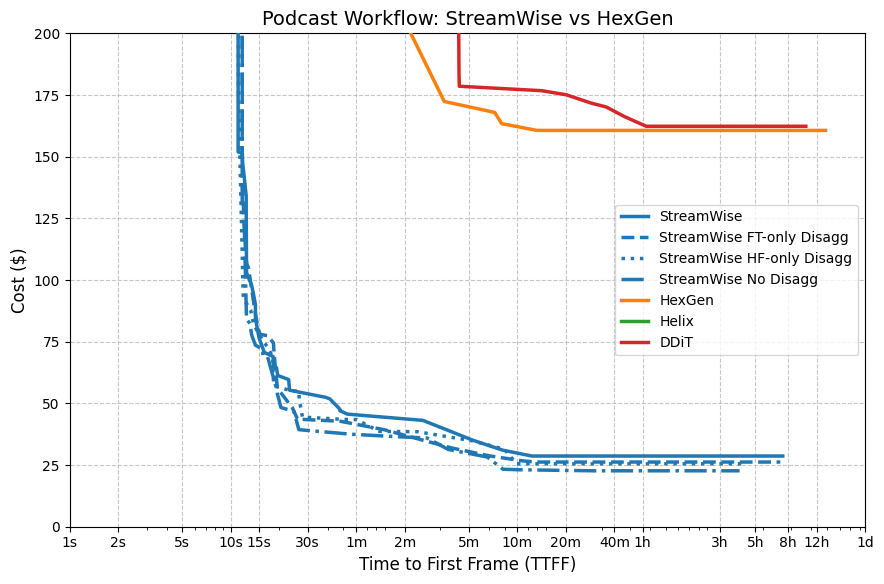

In [16]:
plot_pareto_comparison(
    [
        (streamwise_results, "StreamWise"),
        (streamwise_ft_only_disagg_results, "StreamWise FT-only Disagg"),
        (streamwise_hf_only_disagg_results, "StreamWise HF-only Disagg"),
        (streamwise_no_disagg_results, "StreamWise No Disagg"),
        # (hexgen_results, "HexGen"),
        (hexgen_cost_aware_results, "HexGen"),
        (helix_results, "Helix"),
        (ddit_results, "DDiT"),
    ],
    xmin=10,
    xmax=1 * SECONDS_IN_HOUR,
    ymax=200,
    # yscale="log",
    frontier_line_only=True,
)

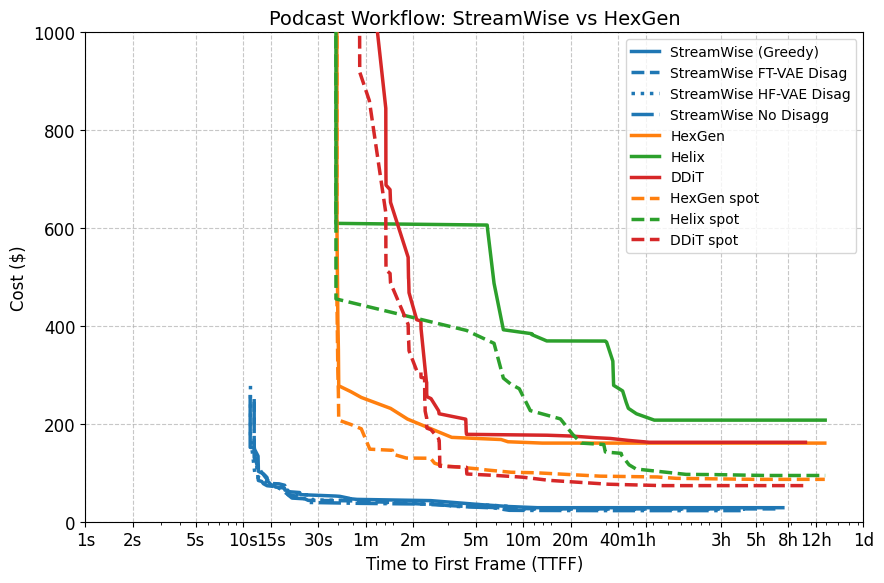

In [17]:
plot_pareto_comparison(
    [
        (streamwise_results, "StreamWise (Greedy)"),
        (streamwise_ft_only_disagg_results, "StreamWise FT-VAE Disag"),
        (streamwise_hf_only_disagg_results, "StreamWise HF-VAE Disag"),
        (streamwise_no_disagg_results, "StreamWise No Disagg"),
        (hexgen_cost_aware_results, "HexGen"),
        (helix_results, "Helix"),
        (ddit_results, "DDiT"),
        (hexgen_results_using_spot_cost_aware, "HexGen spot"),
        (helix_results_using_spot, "Helix spot"),
        (ddit_results_using_spot, "DDiT spot"),
    ],
    xmin=5,
    xmax=5 * SECONDS_IN_HOUR,
    ymax=1000,
    # yscale="log",
    frontier_line_only=True,
)

## Save results

In [18]:
streamwise_results.save("streamwise", results_dir=results_llm_dir)
streamwise_ft_only_disagg_results.save("streamwise_ft_vae", results_dir=results_llm_dir)
streamwise_hf_only_disagg_results.save("streamwise_hf_vae", results_dir=results_llm_dir)
streamwise_no_disagg_results.save("streamwise_no_disagg", results_dir=results_llm_dir)

hexgen_cost_aware_results.save("hexgen", results_dir=results_llm_dir)
helix_results.save("helix", results_dir=results_llm_dir)
ddit_results.save("ddit", results_dir=results_llm_dir)

hexgen_results_using_spot_cost_aware.save("hexgen_spot", results_dir=results_llm_dir)
helix_results_using_spot.save("helix_spot", results_dir=results_llm_dir)
ddit_results_using_spot.save("ddit_spot", results_dir=results_llm_dir)

## Per-GPU-Type Breakdown

Scatter plots split by GPU type for each policy, with Pareto frontiers overlaid.

In [19]:
def plot_per_gpu_comparison(
    results_list: dict[str, ProvisioningResult],
    xmin: float = 15,
    xmax: float = 5 * SECONDS_IN_HOUR,
    figsize_per_cell: tuple[int, int] = (7, 5),
):
    """TTFF vs Cost scatter plots per GPU type for multiple policies.

    Parameters
    ----------
    results_list : dict of str to ProvisioningResult
        Each entry is a (label, ProvisioningResult) pair.
    figsize_per_cell : tuple
        (width, height) of each individual subplot cell.
    """
    n = len(results_list)
    ncols = min(n, 2)
    nrows = math.ceil(n / ncols)
    figsize = (
        figsize_per_cell[0] * ncols,
        figsize_per_cell[1] * nrows
    )

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=False, squeeze=False)
    plt.rcParams.update({"font.size": 11})

    colors = get_color_map()
    gpu_markers = {
        "A100": "o",
        "H100": "^",
        "H200": "s",
        "GB200": "D"}

    for idx, (label, res) in enumerate(results_list.items()):
        row, col = divmod(idx, ncols)
        ax = axes[row][col]

        provisions = res.actual_provision

        # Plot by GPU type
        for gpu_idx, gpu_type in enumerate(GPUType):
            idxs = [
                i for i, p in enumerate(provisions)
                if p.get(gpu_type, 0) > 0 and len(p) == 1
            ]
            if idxs:
                ax.scatter(
                    [res.ttffs[i] for i in idxs],
                    [res.costs[i] for i in idxs],
                    s=50,
                    color=colors[gpu_idx + 1],
                    marker=gpu_markers.get(gpu_type.name, "o"),
                    label=gpu_type.name,
                    alpha=0.6,
                )

        # Mixed
        single_idxs = set()
        for gpu_type in GPUType:
            for i, p in enumerate(provisions):
                if p.get(gpu_type, 0) > 0 and len(p) == 1:
                    single_idxs.add(i)
        mixed_idxs = [i for i in range(len(provisions)) if i not in single_idxs]
        if mixed_idxs:
            ax.scatter(
                [res.ttffs[i] for i in mixed_idxs],
                [res.costs[i] for i in mixed_idxs],
                s=40,
                color=colors[0],
                marker="x",
                label="Mixed",
                alpha=0.4,
            )

        # Pareto frontier
        pareto = get_pareto_frontier(res.ttffs, res.costs)
        ax.plot(
            pareto[:, 0],
            pareto[:, 1],
            color="black",
            linewidth=2,
            label="Frontier",
            zorder=5)

        ax.set_xscale("log")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0)

        ticks, tick_labels = _get_time_ticklabels()
        ax.set_xticks(ticks)
        ax.set_xticklabels(tick_labels)

        ax.set_xlabel("Time to First Frame (TTFF)", fontsize=11)
        ax.set_title(label, fontsize=13)
        ax.grid(True, linestyle="--", alpha=0.7)
        ax.legend(fontsize=9)

        if col == 0:
            ax.set_ylabel("Cost ($)", fontsize=11)

    # Hide unused axes
    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].set_visible(False)

    plt.suptitle("Podcast Workflow — GPU Breakdown", fontsize=14, y=1.02)
    plt.tight_layout(pad=0)
    plt.show()

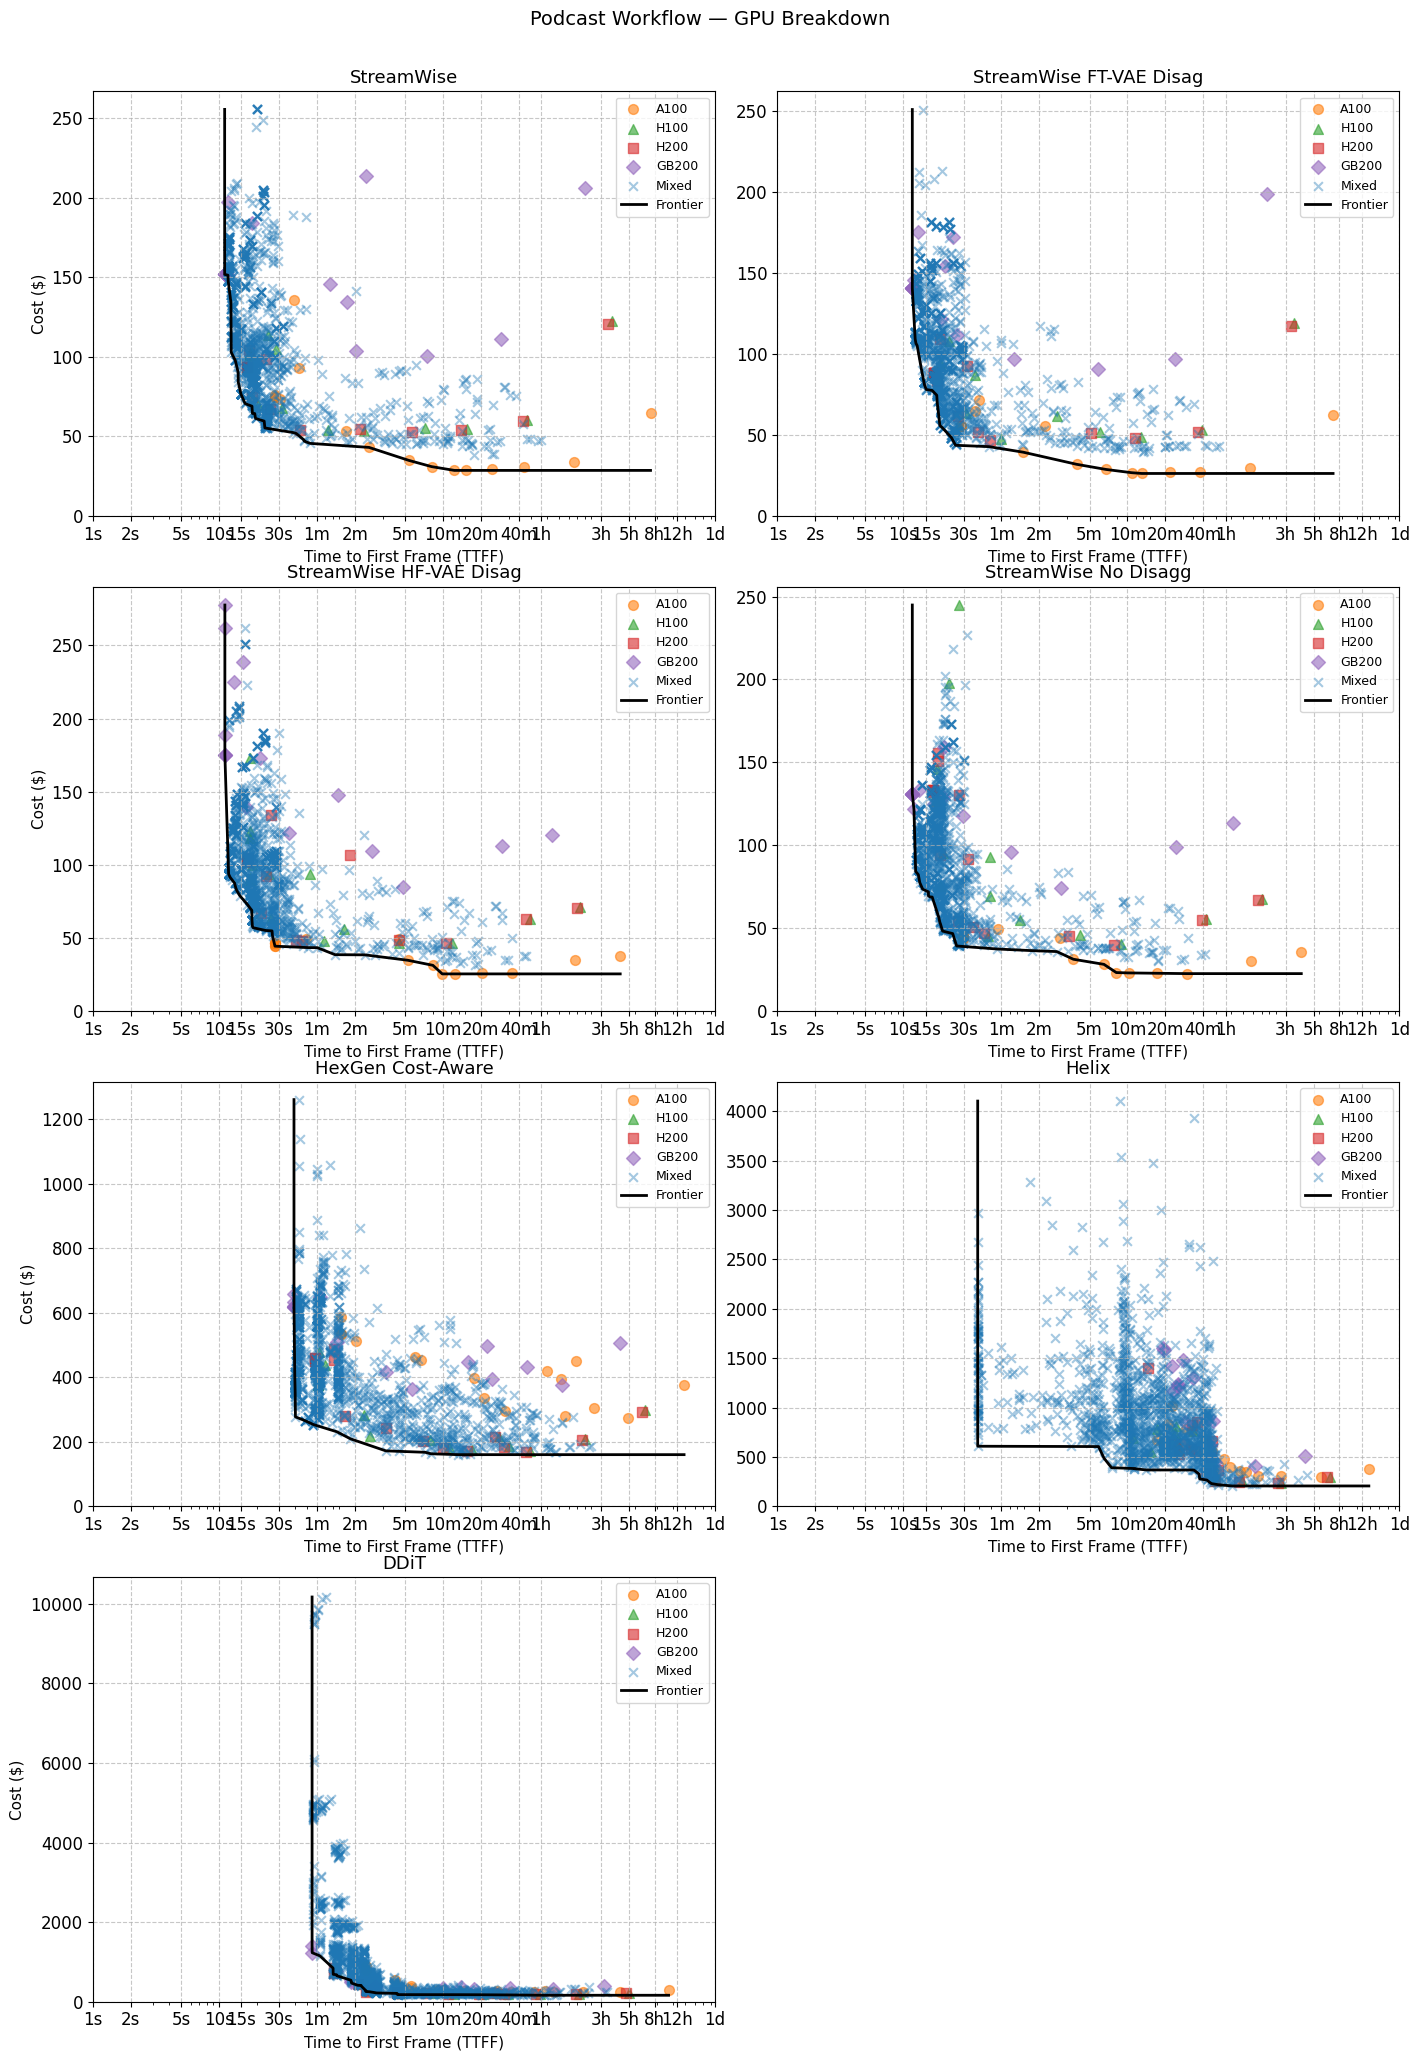

In [20]:
plot_per_gpu_comparison(
    {
        "StreamWise": streamwise_results,
        "StreamWise FT-VAE Disag": streamwise_ft_only_disagg_results,
        "StreamWise HF-VAE Disag": streamwise_hf_only_disagg_results,
        "StreamWise No Disagg": streamwise_no_disagg_results,
        # "HexGen": hexgen_results,
        "HexGen Cost-Aware": hexgen_cost_aware_results,
        "Helix": helix_results,
        "DDiT": ddit_results,
    },
    xmin=5,
    xmax=16 * SECONDS_IN_HOUR,
)